In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
from sklearn.preprocessing import PolynomialFeatures


In [3]:
df = pd.read_csv('/content/StudentPerformanceFactors.csv')

In [4]:
print(df.head())
print(df.info())
print(df.describe())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [5]:
print(df.isnull().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [44]:
df = df.dropna()
df.drop_duplicates(inplace=True)

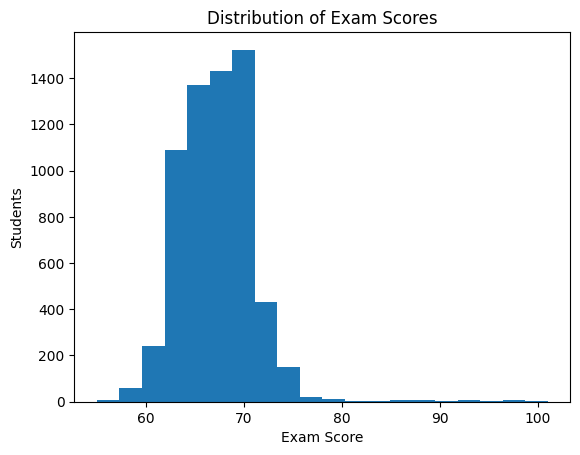

In [45]:
plt.hist(df["Exam_Score"], bins=20)

plt.xlabel("Exam Score")
plt.ylabel("Students")
plt.title("Distribution of Exam Scores")
plt.show()

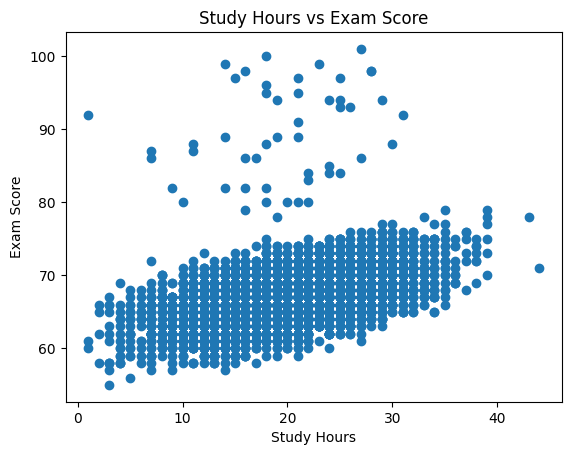

In [46]:
plt.scatter(df["Hours_Studied"], df["Exam_Score"])

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")

plt.show()

In [55]:
correlation = df.corr(numeric_only=True)

print(correlation["Exam_Score"].sort_values(ascending=False))

Exam_Score                               1.000000
Attendance                               0.580259
Hours_Studied                            0.445104
Previous_Scores                          0.174283
Tutoring_Sessions                        0.156829
Parental_Education_Level_Postgraduate    0.092247
Distance_from_Home_Near                  0.081204
Peer_Influence_Positive                  0.080236
Extracurricular_Activities_Yes           0.063063
Internet_Access_Yes                      0.051124
Physical_Activity                        0.025148
Family_Income_Medium                     0.024922
Motivation_Level_Medium                  0.022508
Gender_Male                             -0.004932
Peer_Influence_Neutral                  -0.007472
School_Type_Public                      -0.010868
Sleep_Hours                             -0.017171
Access_to_Resources_Medium              -0.024579
Parental_Involvement_Medium             -0.036191
Teacher_Quality_Low                     -0.040883


In [48]:
X1 = df[["Hours_Studied"]]
Y = df["Exam_Score"]

In [50]:
X2 = df[["Hours_Studied", "Attendance"]]

In [49]:
X3 = df[["Hours_Studied", "Attendance", "Previous_Scores", "Tutoring_Sessions"]]

In [78]:
def train_and_evaluate(X, Y, model_name):
  X_train, X_test, Y_train, Y_test = train_test_split(
      X, Y, test_size=0.2, random_state=42
  )
  model = LinearRegression()
  model.fit(X_train, Y_train)

  prediction = model.predict(X_test)

  print(f"\n{model_name}")
  print("-" * 30)
  print("MAE:", mean_absolute_error(Y_test, prediction))
  print("MSE:", mean_squared_error(Y_test, prediction))
  print("RMSE:", np.sqrt(mean_squared_error(Y_test, prediction)))
  print("R2:", r2_score(Y_test, prediction))

  plt.figure(figsize=(6,6))
  plt.scatter(Y_test, prediction, alpha=0.7)
  plt.plot(
      [Y_test.min(), Y_test.max()],
      [Y_test.min(), Y_test.max()],
      'r--'
  )
  plt.xlabel("Actual Exam Score")
  plt.ylabel("Predicted Exam Score")
  plt.title("Actual vs Predicted Exam Scores")
  plt.show()


# Polynomial Regression
  poly = PolynomialFeatures(degree=2)

  X_train_poly = poly.fit_transform(X_train)
  X_test_poly = poly.transform(X_test)

  poly_model = LinearRegression()
  poly_model.fit(X_train_poly, Y_train)

  poly_prediction = poly_model.predict(X_test_poly)
  print("Original shape:", X_train.shape)
  print("Polynomial shape:", X_train_poly.shape)

  print(f"\nPolynomial Regression for {model_name}")
  print("-" * 30)
  print("MAE:", mean_absolute_error(Y_test, poly_prediction))
  print("MSE:", mean_squared_error(Y_test, poly_prediction))
  print("RMSE:", np.sqrt(mean_squared_error(Y_test, poly_prediction)))
  print("R2:", r2_score(Y_test, poly_prediction))




Model 1: Hours Studied
------------------------------
MAE: 2.529242069526125
MSE: 12.351733799445535
RMSE: 3.5145033503249836
R2: 0.2051306083246669


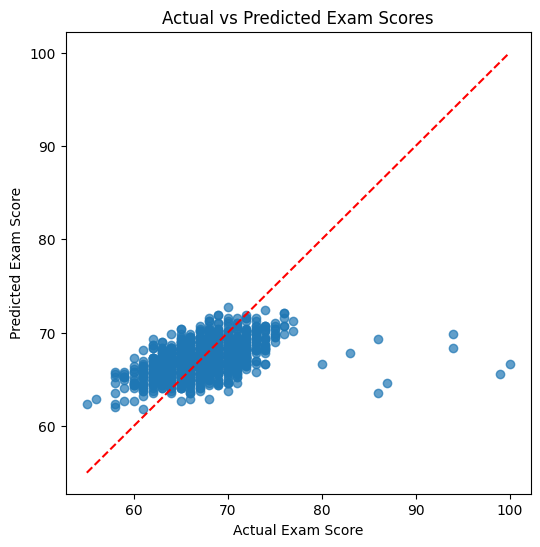

Original shape: (5102, 1)
Polynomial shape: (5102, 3)

Polynomial Regression for Model 1: Hours Studied
------------------------------
MAE: 2.528560941765644
MSE: 12.352544212816404
RMSE: 3.5146186440091056
R2: 0.2050784559067499

Model 2: Hours Studied + Attendance
------------------------------
MAE: 1.529916570354573
MSE: 7.017679347898187
RMSE: 2.6490902868528634
R2: 0.5483922658301801


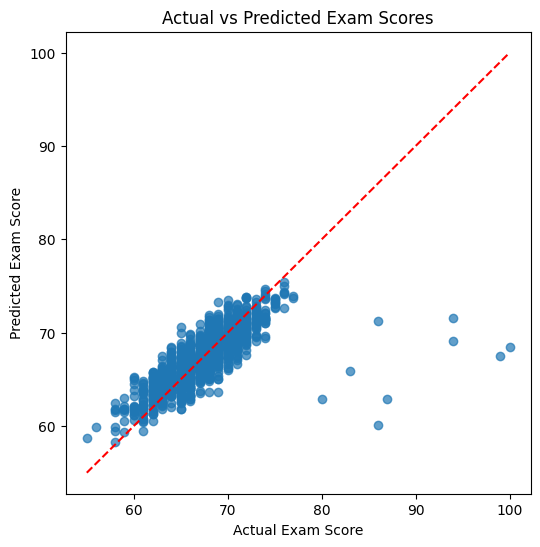

Original shape: (5102, 2)
Polynomial shape: (5102, 6)

Polynomial Regression for Model 2: Hours Studied + Attendance
------------------------------
MAE: 1.5314733052770297
MSE: 7.029203205459823
RMSE: 2.651264454078435
R2: 0.5476506726418471

Model 3: Hours Studied + Attendance + Previous_Scores + Tutoring_Sessions
------------------------------
MAE: 1.3299277983701445
MSE: 6.0674121098043505
RMSE: 2.4632117468468584
R2: 0.6095446800367227


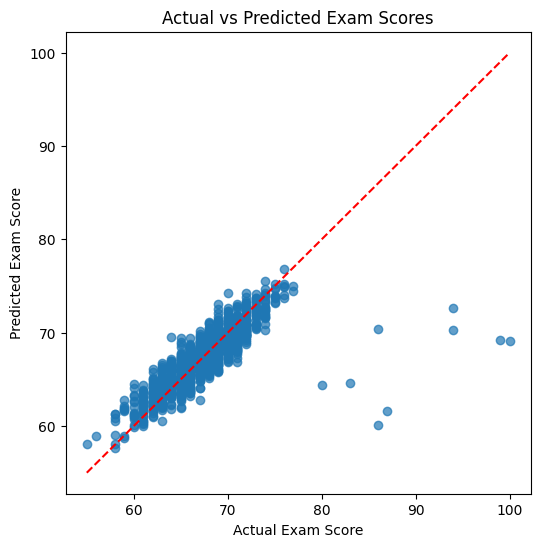

Original shape: (5102, 4)
Polynomial shape: (5102, 15)

Polynomial Regression for Model 3: Hours Studied + Attendance + Previous_Scores + Tutoring_Sessions
------------------------------
MAE: 1.3336428595952359
MSE: 6.071743343063145
RMSE: 2.4640907741118516
R2: 0.6092659527906922


In [79]:
train_and_evaluate(X1, Y, "Model 1: Hours Studied")
train_and_evaluate(X2, Y, "Model 2: Hours Studied + Attendance")
train_and_evaluate(X3, Y, "Model 3: Hours Studied + Attendance + Previous_Scores + Tutoring_Sessions")